# 📘 Seaborn Practice — Task 26 Solutions

**Type:** SOLUTIONS WALKTHROUGH · **Level:** 🟠 Intermediate

## About this notebook

This is the fully solved version of Task 26. Every problem — from the original task notebook — is answered here with working code, so you can compare your attempt, study the intended approach and pick up the exact API details. Work through each problem statement first, then read the solution and ask yourself **why** each argument is present.

You will see the whole categorical-plus-multivariate toolbox again, now with concrete solutions:

- **Categorical distribution**: `sns.violinplot` (diamonds' price by cut) and `sns.catplot(kind='box')` for price by color.
- **Regression with hue / faceting**: `sns.lmplot(data, x='carat', y='price', hue='cut')` and the faceted `col='cut', col_wrap=3` variant.
- **Categorical estimate**: `sns.catplot(kind='point')` for mean fare by payment type.
- **Feature engineering**: computing `ride_time` from `pickup` and `dropoff` timestamps, then regressing it against `total` fare with `hue`.
- **The insurance full sweep** (problems 5–12): strip/swarm, box/violin with `split`, bar/point, regplot, pairplot, PairGrid, jointplot and JointGrid.

The datasets: `diamonds` (~54k stones), `taxis` (NYC trips), and the patient-insurance CSV (columns `index`, `PatientID`, `age`, `gender`, `bmi`, `bloodpressure`, `diabetic`, `children`, `smoker`, `region`, `claim`).

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### `Q 1-3` Using the 'diamonds' dataset - sns.load_dataset('diamonds')
1. Create a violinplot of 'price' grouped by 'cut'.
2. Create regplot on `carat` vs `price`. and give hue on 'cut'
3. Create boxplot on 'color' and 'price'

## Q 1–3 — Diamonds: violin, regression and box (solved)

**Concept.** The three diamonds problems each pick a different plot family for the same data, and the solutions reuse them in their most convenient form:

- `sns.violinplot(data=df, x='cut', y='price')` — price distribution by cut quality; each violin is a mirrored KDE with a mini box inside, so denser price ranges appear wider.
- `sns.lmplot(data=df, x='carat', y='price', hue='cut')` — scatter + fitted regression per cut. Because `lmplot` is figure-level, `hue` works automatically and each cut gets its own line and confidence band. The `col='cut', col_wrap=3` variant facets five separate panels (wrapping after 3 columns), each with its own regression line.
- `sns.catplot(data=df, x='color', y='price', kind='box')` — boxplot of price per diamond color grade.

**Hint.** `df = sns.load_dataset('diamonds')` and `.shape` confirms 53940 rows, 10 columns; `.head()` shows `carat`, `cut`, `color`, `clarity`, `price` etc. Use the figure-level calls (`lmplot`, `catplot`) so legends and facets come free.

In [2]:
# code here
df = sns.load_dataset('diamonds')

In [3]:
print(df.shape)
df.head()

(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<Axes: xlabel='cut', ylabel='price'>

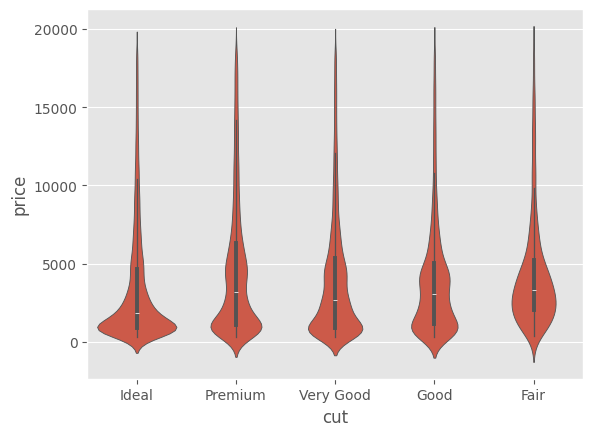

In [4]:
sns.violinplot(data=df,x='cut',y='price')

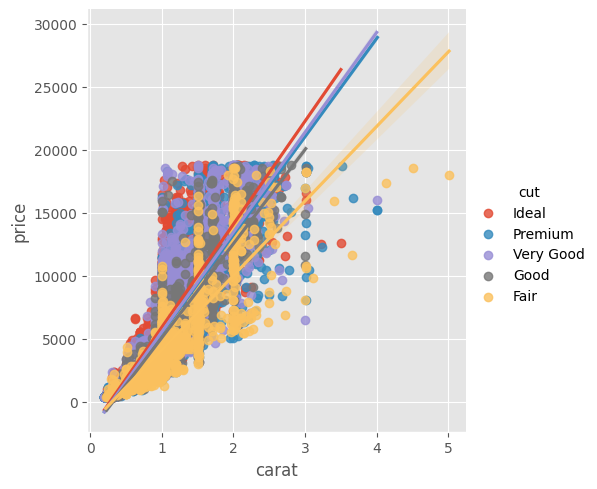

In [5]:
sns.lmplot(data=df,x='carat',y='price',hue='cut')

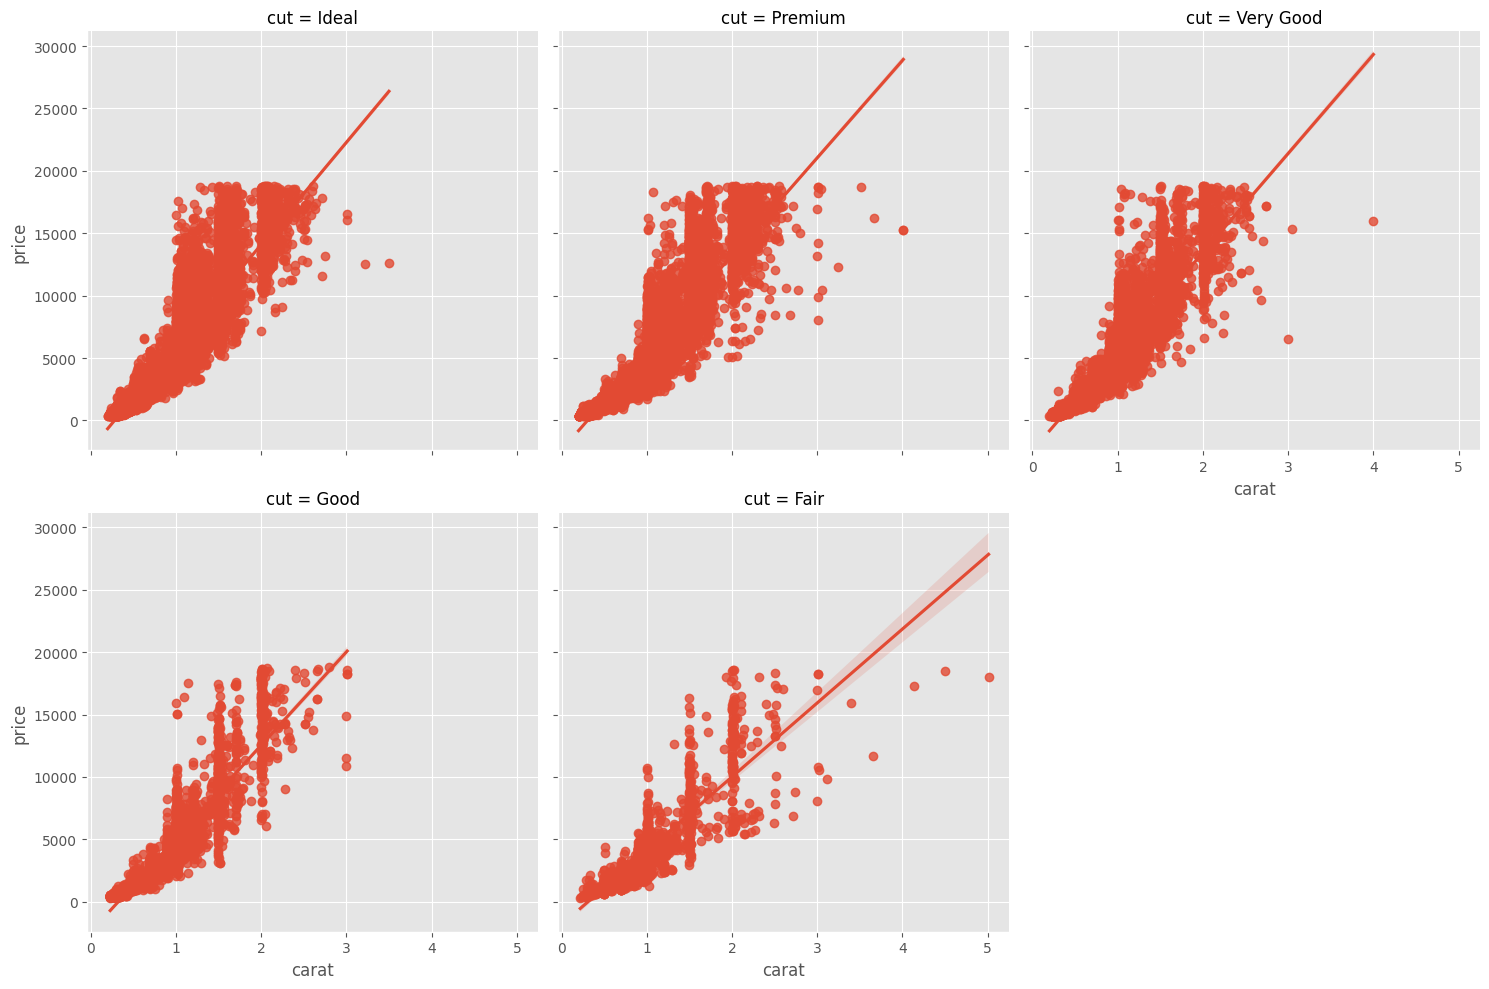

In [6]:
sns.lmplot(data=df,x='carat',y='price',col='cut',col_wrap=3)

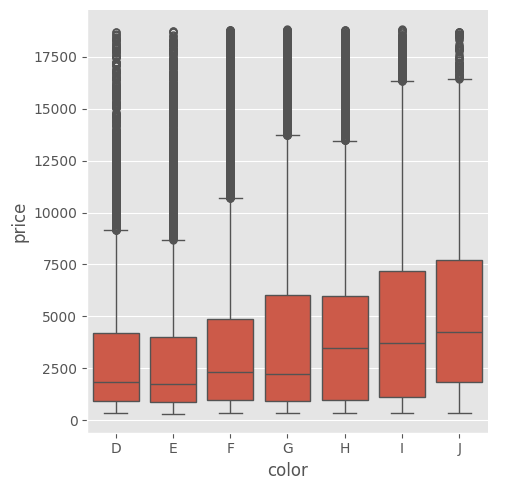

In [7]:
sns.catplot(data=df,x='color',y='price',kind='box')

###`Q 4` Using the 'Taxis' dataset - sns.load_dataset('taxis')
4.1. Create a categorical estimate plot of the totl fare - 'total' for each payment type - 'payment'.

4.2. Create a regression plot on time of ride  vs total fare. You will need to calculate ride time using pickup and dropoff column. 

4.3 Give hue on payment type. and Another plot hue on taxi 'color'. Observe the plot.

## Q 4 — Taxis: estimate plot and ride-time regression (solved)

**Concept.** The taxis dataset (`sns.load_dataset('taxis')`, 6433 rows) drives two ideas. First, a **categorical estimate plot**: `sns.catplot(data=df, x='payment', y='total', kind='point')` plots the mean total fare per payment type (cash/credit card) with vertical confidence lines. Second, an engineered feature: `df['ride_time']` is computed as `pd.to_datetime(df['dropoff']) - pd.to_datetime(df['pickup'])`, then converted to minutes with `round(df['ride_time'].dt.total_seconds() / 60, 2)`. That numeric column becomes the x of three regressions: `sns.lmplot(data=df, x='ride_time', y='total')` (plain), and the same call adding `hue='color'` (taxi color) and `hue='payment'`.

**Hint.** `df.info()` shows `pickup`/`dropoff` are already `datetime64`, which is why subtraction yields a timedelta and `.dt.total_seconds()` works. Observe how the slope of total-over-ride-time changes (or does not) between the two `hue` splits.

In [8]:
# code here
df = sns.load_dataset('taxis')

In [9]:
df.shape

(6433, 14)

In [10]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


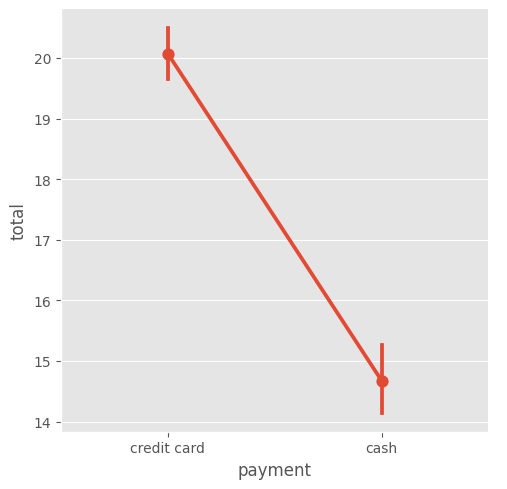

In [11]:
sns.catplot(data=df,x='payment',y='total',kind='point')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [13]:
df['ride_time'] = pd.to_datetime(df['dropoff']) - pd.to_datetime(df['pickup'])

In [14]:
df['ride_time'] = round(df['ride_time'].dt.total_seconds()/60,2)

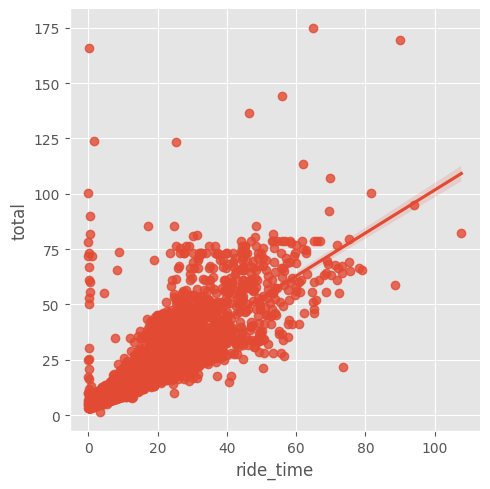

In [15]:
sns.lmplot(data=df,x='ride_time',y='total')

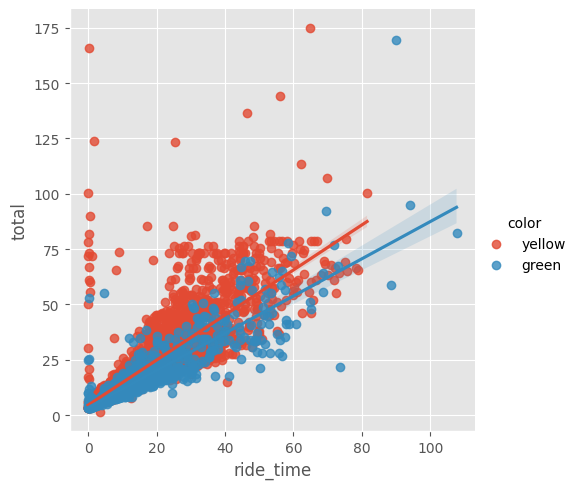

In [16]:
sns.lmplot(data=df,x='ride_time',y='total',hue='color')

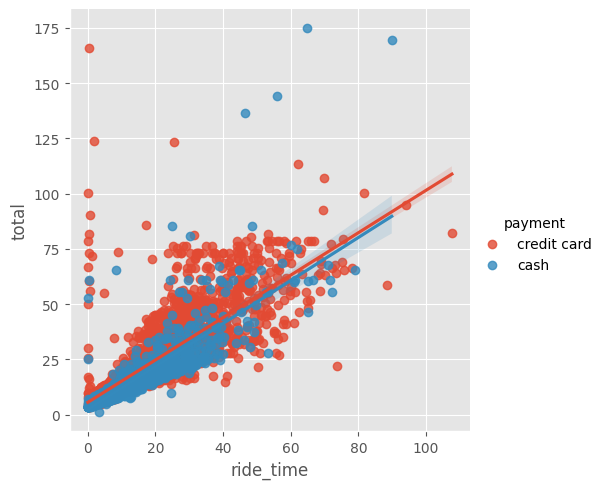

In [17]:
sns.lmplot(data=df,x='ride_time',y='total',hue='payment')

## Problem 5-12:

Dataset Link - https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/pub?gid=220677750&single=true&output=csv

### **`Problem 5:`** Draw a strip plot and swarm plot between "gender" and "bloodpressure" w.r.t "smoker" (use as hue parameter). Also add title to the charts.

## Problems 5–12 — The insurance dataset

**Concept.** Five flagged problems all run on the insurance CSV, loaded directly from its Google-Sheets URL: `df = pd.read_csv('https://...output=csv')`. Available columns: `index`, `PatientID`, `age`, `gender`, `bmi`, `bloodpressure`, `diabetic`, `children`, `smoker`, `region`, `claim`. Reused patterns to expect in every solution cell ahead:

- **categorical semantic channels**: `hue` on `smoker`/`diabetic`/`gender`; `split` on violins; `kind='strip'|'swarm'|'box'|'violin'|'bar'|'point'` via `sns.catplot`.
- **`plt.title(...)` directly after the seaborn call** to add a human-readable title (e.g. `'BP Vs Gender vs Smoker'`, `'Region vs bmi vs diabetic'`).
- **`df.drop(columns=['index', 'PatientID'])`** before pair plots and grids, so the useless identifier columns never pollute the pair matrices.
- **`.dropna()`** health check where missing values would break clustering (the frame contains a handful of NaNs).

**Problem 5 — strip & swarm (solved).** `sns.catplot(data=df, kind='strip', x='gender', y='bloodpressure', hue='smoker')` jitters every blood-pressure reading per gender with smoker as color; the swarm twin uses the same call with `kind='swarm'` and packs points without overlap. Note the swarm's warning in the output — "12.2% of the points cannot be placed" — a real reminder that swarm decks can saturate, which is precisely why stripplot exists as the fallback.

In [18]:
# code here
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/pub?gid=220677750&single=true&output=csv')
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


Text(0.5, 1.0, 'BP Vs Gender vs Smoker')

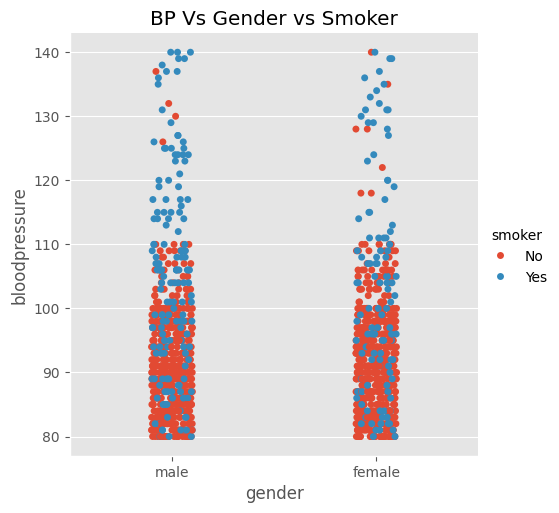

In [19]:
sns.catplot(data=df,kind='strip',x='gender',y='bloodpressure',hue='smoker')
plt.title('BP Vs Gender vs Smoker')

C:\Users\RAVNOOR SINGH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\RAVNOOR SINGH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\RAVNOOR SINGH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\RAVNOOR SINGH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use

Text(0.5, 1.0, 'BP Vs Gender vs Smoker')

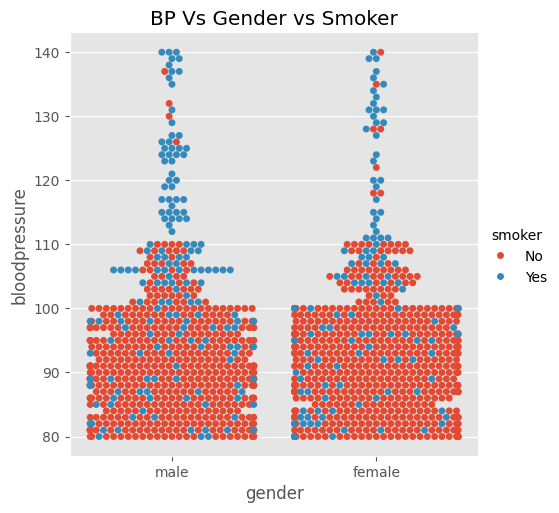

In [20]:
sns.catplot(data=df,kind='swarm',x='gender',y='bloodpressure',hue='smoker')
plt.title('BP Vs Gender vs Smoker')

### **`Problem 6:`** Draw a Box-plot and a Violin plot of which x-axis represents the "region" and the y-axis represents the "bmi". Also add extra information of the column "diabetic".

## Problem 6 — Box & violin: region, bmi, diabetic (solved)

**Concept.** Two categorical-distribution solutions, structurally identical:

- `sns.catplot(data=df, x='region', y='bmi', hue='diabetic', kind='box')` — one box per region, split into diabetic vs non-diabetic colors; medians, IQRs and outliers visible.
- `sns.catplot(data=df, x='region', y='bmi', hue='diabetic', kind='violin', split=True)` — the density version; `split=True` halves each violin so the two diabetic groups share one shape.

**Hint.** Run both and title each `'Region vs bmi vs diabetic'`. The violin's extra width shows where BMI values are concentrated, which the plain box hides.

Text(0.5, 1.0, 'Region vs bmi vs diabetic')

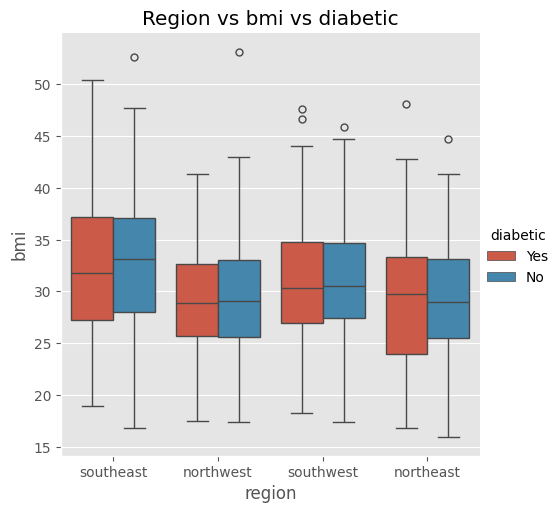

In [21]:
# code here
sns.catplot(data = df, x = 'region', y = 'bmi', hue = 'diabetic', kind = 'box')
plt.title('Region vs bmi vs diabetic')

Text(0.5, 1.0, 'Region vs bmi vs diabetic')

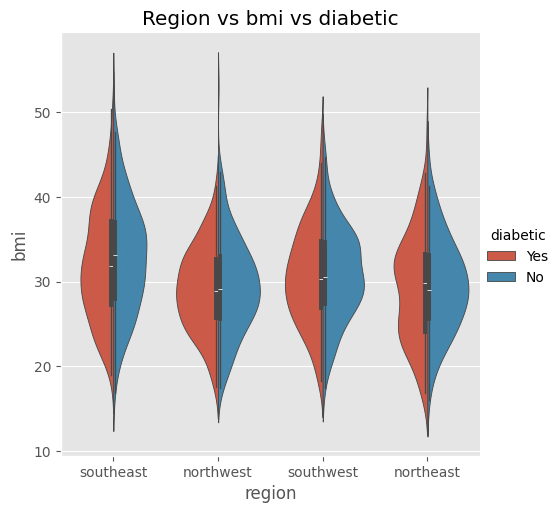

In [22]:
sns.catplot(data = df, x = 'region', y = 'bmi', hue = 'diabetic', kind = 'violin', split = True)
plt.title('Region vs bmi vs diabetic')

### **`Problem  7:`** Draw a bar plot and point plot of which x-axis represents the "gender" and y-axis represents "claim". Also add extra information about "smoker" column.

## Problem 7 — Bar & point: gender, claim, smoker (solved)

**Concept.** The estimate family, side by side in one row of subplots: `fig, ax = plt.subplots(1, 2, figsize=(12, 5))`. `sns.barplot(x='gender', y='claim', hue='smoker', data=df, ax=ax[0])` draws the mean claim with confidence bars for each gender/smoker combo; `sns.pointplot(..., ax=ax[1])` renders the same means as connected points with error caps. Both use the same `hue` so the smoker gap is directly comparable across the two representations.

**Hint.** The `ax=` arguments are what route each chart into its panel — call the barplot on `ax[0]`, the pointplot on `ax[1]`, then `plt.show()`.

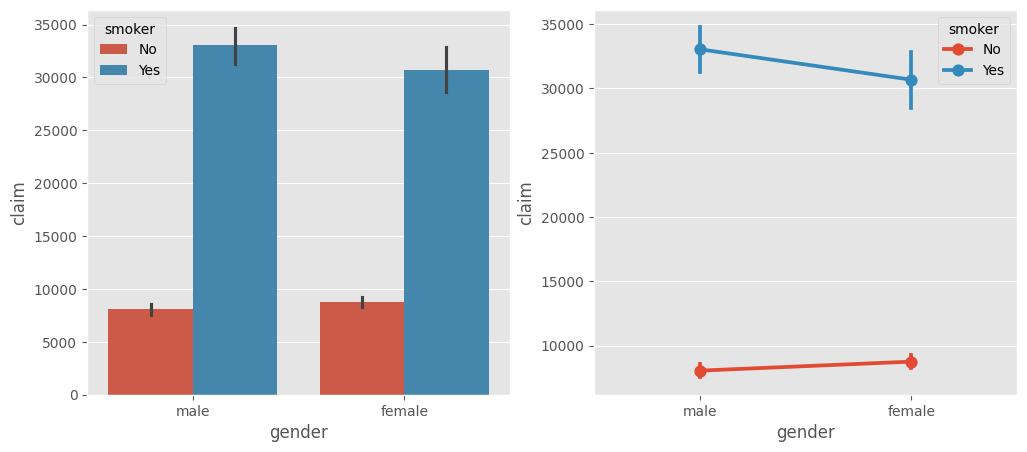

In [23]:
# code here
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.barplot(x='gender',y='claim',hue='smoker',data=df,ax=ax[0])

sns.pointplot(x='gender',y='claim',hue='smoker',data=df,ax=ax[1])

plt.show()

### **`Problem 8:`** Draw a reg plot between "age" and "bmi" columns.

## Problem 8 — Regplot: age vs BMI (solved)

**Concept.** `sns.regplot(x='bmi', y='age', data=df)` — the solution happens to place BMI on x and age on y, but the problem's "reg plot between age and bmi" is satisfied either way; `regplot` is axes-level, draws onto the current axes, and adds the best-fit line plus confidence band.

**Hint.** Look at the slope: if BMI rises with age, the fit line climbs; a confidence band that stays tight means the relationship is persuasive. Compare quickly with `sns.lmplot(...)` if you want the same fit with `hue` added.

<Axes: xlabel='bmi', ylabel='age'>

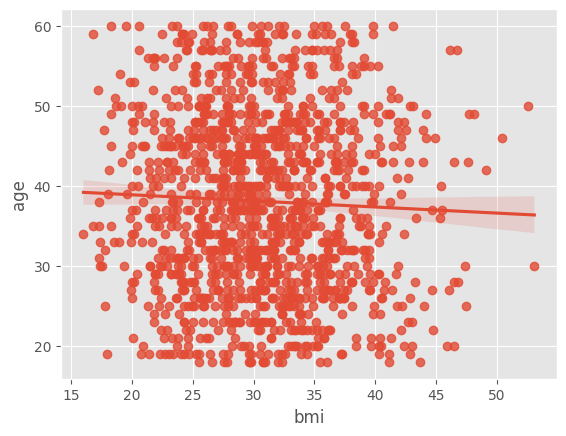

In [24]:
# code here
sns.regplot(x='bmi', y='age', data=df)

### **`Problem 9:`** Draw a pair plot of the insurance data. Use "gender" as hue parameter.

## Problem 9 — Pairplot by gender (solved)

**Concept.** `sns.pairplot(data=df.drop(columns=['index', 'PatientID']), hue='gender')` builds the full matrix of every numeric column against every other. The diagonal shows each variable's marginal distribution per gender; the off-diagonal cells show pairwise scatters, all split by `hue='gender'`. Dropping `index`/`PatientID` is essential — keeping them would produce meaningless index-vs-value pairs that dominate the grid.

**Hint.** Scan the matrix for cells where the male/female color clouds separate cleanly; those are the variables that genuinely differ between genders.

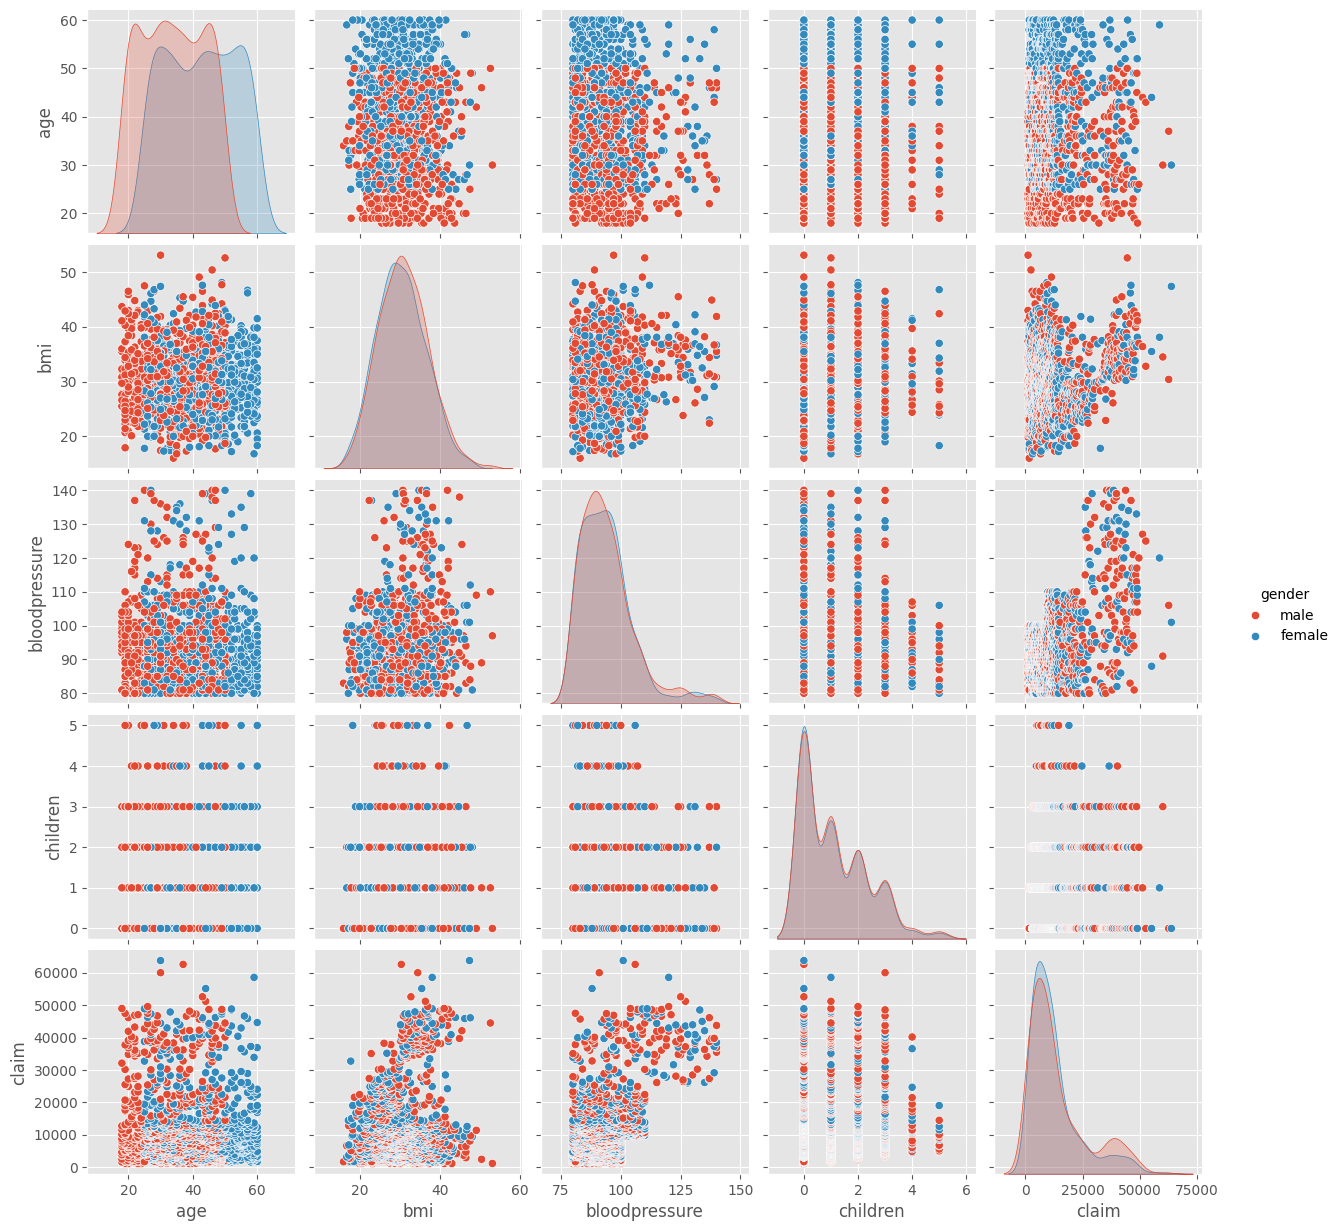

In [25]:
# code here
sns.pairplot(data=df.drop(columns=['index',	'PatientID']),hue='gender')

### **`Problem 10:`** Draw a pair grid of the insurance data and use "diabetic" column as a hue parameter. Also, make the diagonal plots as box-plot, upper parts as scatter plot and the lower parts as kde plot.

## Problem 10 — PairGrid, region by region (solved)

**Concept.** `g = sns.PairGrid(df.drop(columns=['index', 'PatientID']), hue='diabetic')` creates the empty grid, then three `map_*` calls fill different regions with different plot types:

- `g.map_diag(sns.boxplot)` — each variable's boxplot per diabetic status on the diagonal.
- `g.map_upper(sns.scatterplot)` — scatter in the upper triangle.
- `g.map_lower(sns.kdeplot)` — density contours in the lower triangle.

**Hint.** Mixing types is PairGrid's superpower: boxes for univariate summaries up top, scatters for relationships, KDEs below. Look for whether diabetic patients cluster apart in the KDE cells.

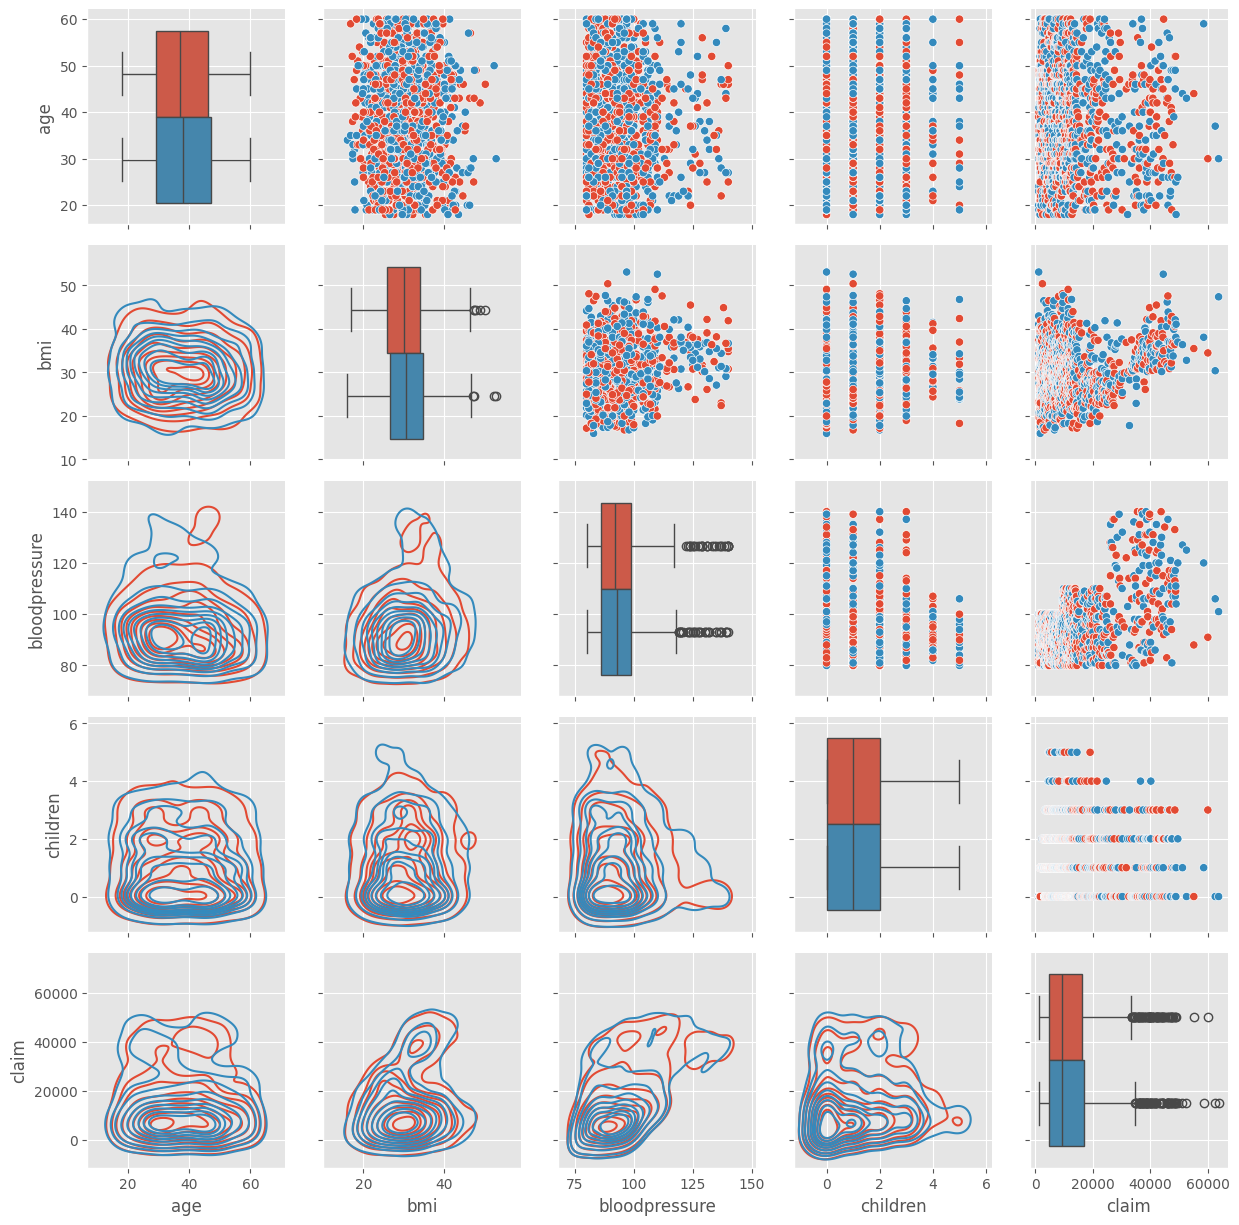

In [26]:
# code here
g = sns.PairGrid(df.drop(columns=['index','PatientID']),hue='diabetic')

g.map_diag(sns.boxplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)

### **`Prolem 11:`** Draw a joint plot as scatter between "bloodpressure" and "bmi". Use "smoker" as hue parameter.

## Problem 11 — Joint plot: bloodpressure vs BMI by smoker (solved)

**Concept.** `sns.jointplot(x='bloodpressure', y='bmi', data=df, kind='scatter', hue='smoker')` couples a central scatter (blood pressure × BMI, colored by smoking) with marginal distributions for each group on the top and right edges. When one group concentrates in a region, its marginals bulge there — an instant multivariate readout.

**Hint.** `kind='scatter'` is explicit here; the same call with `kind='hist'` or `kind='kde'` would switch the center plot without changing the rest of the syntax.

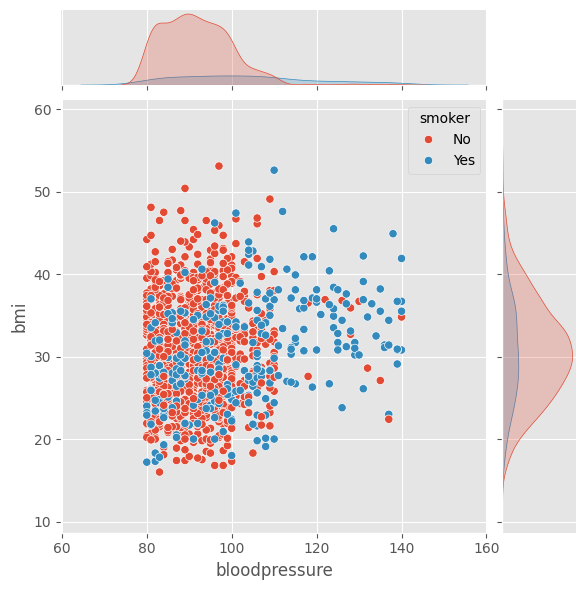

In [27]:
# code here
sns.jointplot(x='bloodpressure', y='bmi', data=df, kind='scatter',hue='smoker')

### **`Problem 12:`** Draw a joint grid of which x-axis represents "age" and y-axis represents "claim". Draw a kdeplot at the center and violinplot for individual variables

## Problem 12 — JointGrid: age vs claim, KDE center + violins (solved)

**Concept.** The manual version: `g = sns.JointGrid(x='age', y='claim', data=df)` draws nothing yet; `g.plot(sns.kdeplot, sns.violinplot)` then places the **2D KDE** of age × claim in the center and a **violin plot** of each variable on the margins. The bivariate contours show where claim amounts concentrate as a function of age, while the marginal violins reveal each variable's full univariate density.

**Hint.** `g.plot(fn_center, fn_marginal, ...)` is the generic contract — any plotting function goes. This is the exact pattern to extend when you need a custom center (hist, scatter, reg) with custom margins.

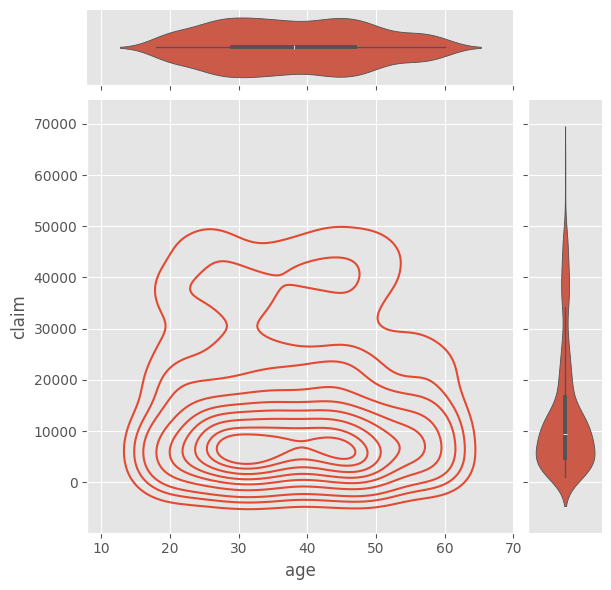

In [28]:
# code here
g = sns.JointGrid(x='age',y='claim',data=df)
g.plot(sns.kdeplot,sns.violinplot)

## Summary

This solutions notebook showed every Task 26 problem answered, and in doing so toured the whole Seaborn toolbox one more time. On `diamonds` you saw violin distributions, hue-stranded regression via `lmplot` (plus its `col=` faceted form) and catplot boxplots. On `taxis` you engineered `ride_time` from pickup/dropoff and regressed it against total fare with `hue` on both `color` and `payment`. Then the insurance fully sweep: strip and swarm with smoker hue (and the swarm-saturation warning), regional box/violin split by diabetic, gender bar/point estimates on subplots, an age–BMI regplot, a gender-colored pairplot, a three-region PairGrid (diag box, upper scatter, lower KDE), a jointplot of blood pressure×BMI by smoker, and a JointGrid placing a 2D KDE against violin margins. Compare each cell with your own attempt, memorize the argument patterns, and the categorical-and-multivariate part of the course is securely yours.